**(1) Combined Cycle Power Plant Data Set**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import f_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

**(a)**
I downloaded the Combined Cycle Power Plant dataset from the UCI Machine Learning Repository.

In [2]:
df = pd.read_excel("../data/CCPP/Folds5x2_pp.xlsx")

**(b)**

**(i)**

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Columns:", df.columns.tolist())
df.head()

Number of rows: 9568
Number of columns: 5
Columns: ['AT', 'V', 'AP', 'RH', 'PE']


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


The dataset has 9,568 rows and 5 columns. Each row represents one hourly observation of the power plant operating at full load. The columns are ambient temperature (AT), exhaust vacuum (V), ambient pressure (AP), relative humidity (RH), and net hourly electrical energy output (PE). The first four are predictors, and the last is the response variable.

**(ii)**

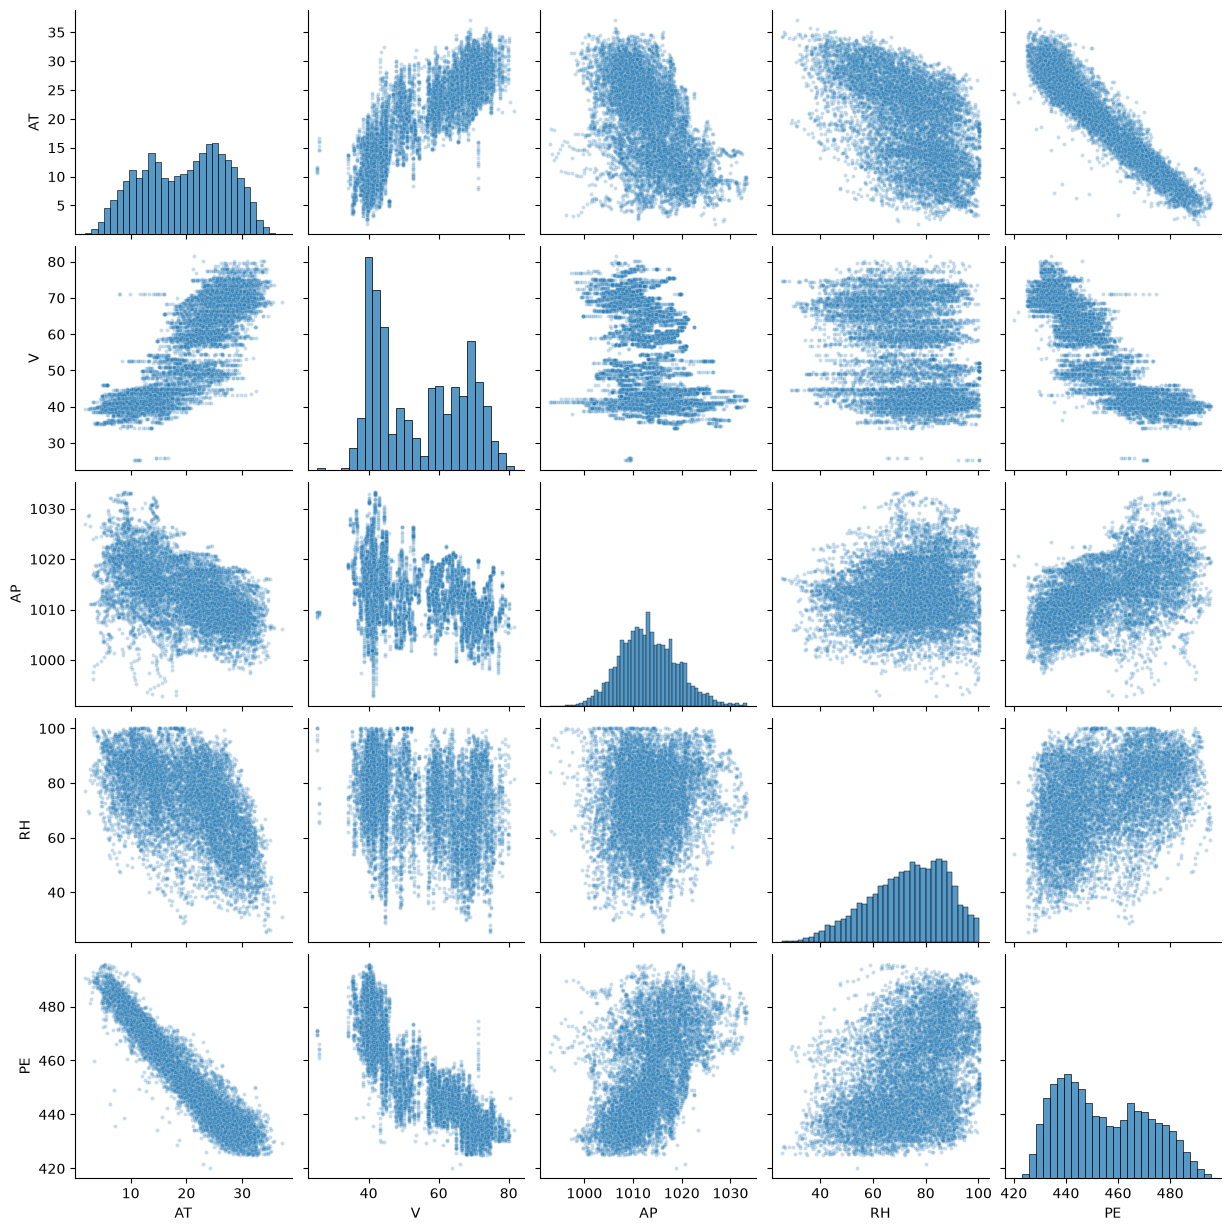

In [4]:
sns.pairplot(
    df,
    diag_kind="hist",
    plot_kws={"alpha": 0.25, "s": 8}
)

plt.show()

The scatterplots show that PE decreases as AT and V increase. These are the clearest relationships with PE. AP has a weaker positive relationship with PE, while RH has a weaker, more scattered positive relationship. AT and V are also positively related.

**(iii)**

In [5]:
summary = pd.DataFrame(index=df.columns)

summary["Mean"] = df.mean()
summary["Median"] = df.median()
summary["Min"] = df.min()
summary["Max"] = df.max()
summary["Range"] = summary["Max"] - summary["Min"]
summary["Q1"] = df.quantile(0.25)
summary["Q3"] = df.quantile(0.75)
summary["IQR"] = summary["Q3"] - summary["Q1"]

display(summary.round(2))

,Mean,Median,Min,Max,Range,Q1,Q3,IQR
AT,19.65,20.34,1.81,37.11,35.30,13.51,25.72,12.21
V,54.31,52.08,25.36,81.56,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,992.89,1033.30,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,25.56,100.16,74.60,63.33,84.83,21.50
PE,454.37,451.55,420.26,495.76,75.50,439.75,468.43,28.68


**(c)**

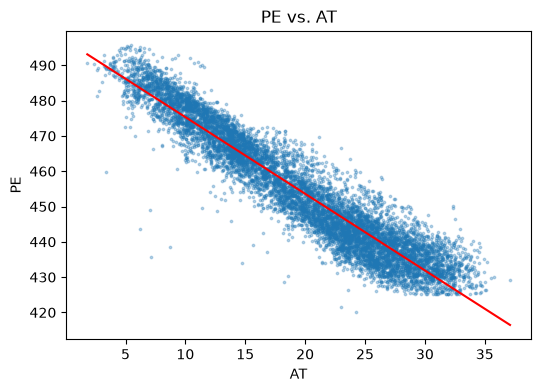

,Predictor,β0,β1,R²,p-value
0,AT,497.0341,-2.1713,0.8989,< 1e-300


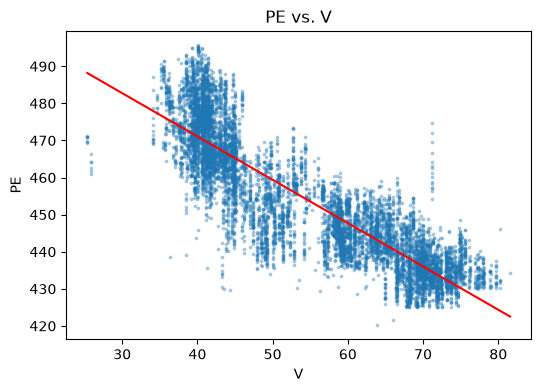

,Predictor,β0,β1,R²,p-value
0,V,517.8015,-1.1681,0.7565,< 1e-300


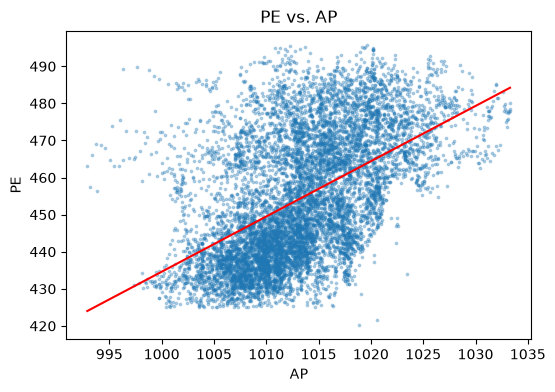

,Predictor,β0,β1,R²,p-value
0,AP,-1055.261,1.4899,0.2688,< 1e-300


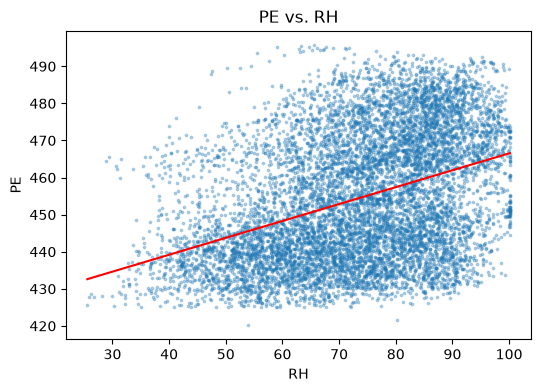

,Predictor,β0,β1,R²,p-value
0,RH,420.9618,0.4557,0.1519,< 1e-300


In [6]:
predictors = ["AT", "V", "AP", "RH"]
y = df["PE"]
simple_coefs = {}

for name in predictors:
    X = df[[name]]
    model = LinearRegression().fit(X, y)
    simple_coefs[name] = model.coef_[0]
    p_value = f_regression(X, y)[1][0]

    plt.figure(figsize=(6, 4))
    plt.scatter(X[name], y, s=3, alpha=0.3)

    X_sorted = X.sort_values(by=name)
    plt.plot(X_sorted[name], model.predict(X_sorted), color="red")

    plt.xlabel(name)
    plt.ylabel("PE")
    plt.title(f"PE vs. {name}")
    plt.show()

    display(pd.DataFrame([{
        "Predictor": name,
        "β0": round(model.intercept_, 4),
        "β1": round(model.coef_[0], 4),
        "R²": round(model.score(X, y), 4),
        "p-value": "< 1e-300" if p_value == 0 else f"{p_value:.2e}"
    }]))

The fitted models show negative relationships between PE and AT and between PE and V. PE has positive relationships with AP and RH. All four associations are statistically significant (p < 0.05). A few observations lie far from the fitted lines, particularly in the AT and V plots. The AP and RH plots also show considerable scatter, but scatter alone does not mean that observations are outliers. These points may be valid measurements that the simple regression models do not explain well. Therefore, I would not remove any observations from the AT, V, AP, or RH regressions.

**(d)**

In [7]:
X_multi = df[predictors]
multi_model = LinearRegression().fit(X_multi, y)

residuals = y.to_numpy() - multi_model.predict(X_multi)
df_residual = len(y) - len(predictors) - 1
residual_variance = (residuals @ residuals) / df_residual

X_values = X_multi.to_numpy()
X_centered = X_values - X_values.mean(axis=0)
coefficient_covariance = residual_variance * np.linalg.inv(
    X_centered.T @ X_centered
)

standard_errors = np.sqrt(np.diag(coefficient_covariance))
t_values = multi_model.coef_ / standard_errors
p_values = 2 * stats.t.sf(np.abs(t_values), df_residual)

summary = pd.DataFrame({
    "Predictor": predictors,
    "Coefficient": multi_model.coef_.round(4),
    "p-value": [
        "< 1e-300" if p == 0 else f"{p:.2e}"
        for p in p_values
    ]
})

print(f"Intercept (β0): {multi_model.intercept_:.4f}")
print(f"R²: {multi_model.score(X_multi, y):.4f}")
display(summary)

Intercept (β0): 454.6093
R²: 0.9287


,Predictor,Coefficient,p-value
0,AT,-1.9775,< 1e-300
1,V,-0.2339,4.38e-215
2,AP,0.0621,5.51e-11
3,RH,-0.1581,3.10e-293


The multiple regression model has an R-squared of 0.9287. Holding the other predictors constant, AT (-1.9775), V (-0.2339), and RH (-0.1581) are negatively associated with PE, while AP (0.0621) is positively associated with PE. All four p-values are below 0.05, so we reject H0: beta_j = 0 for AT, V, AP, and RH.

**(e)**

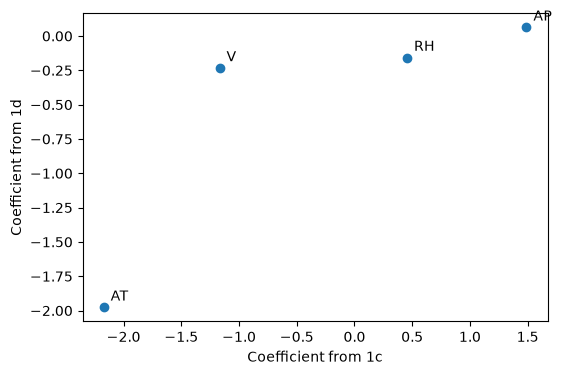

In [8]:
simple_values = [simple_coefs[name] for name in predictors]
multiple_values = multi_model.coef_

plt.figure(figsize=(6, 4))
plt.scatter(simple_values, multiple_values)

for name, x_value, y_value in zip(
    predictors, simple_values, multiple_values
):
    plt.annotate(name, (x_value, y_value),
                 xytext=(5, 5), textcoords="offset points")

plt.xlabel("Coefficient from 1c")
plt.ylabel("Coefficient from 1d")
plt.show()

AT and V have negative coefficients in both models, while AP has a positive coefficient in both. RH changes from positive in 1c to negative in 1d, showing that its estimated relationship with PE changes when the other predictors are included.

**(f)**

In [9]:
results = []
y_values = y.to_numpy()
df_residual = len(y) - 4

def show_p(p):
    return "< 1e-300" if p == 0 else f"{p:.2e}"

for name in predictors:
    x = df[name].to_numpy()

    coefs, covariance = np.polyfit(x, y_values, 3, cov=True)
    beta3, beta2, beta1, beta0 = coefs
    se_beta3, se_beta2 = np.sqrt(np.diag(covariance))[:2]

    p_beta2 = 2 * stats.t.sf(abs(beta2 / se_beta2), df_residual)
    p_beta3 = 2 * stats.t.sf(abs(beta3 / se_beta3), df_residual)

    linear_coefs = np.polyfit(x, y_values, 1)
    sse_linear = np.sum((y_values - np.polyval(linear_coefs, x))**2)
    sse_cubic = np.sum((y_values - np.polyval(coefs, x))**2)

    f_value = ((sse_linear - sse_cubic) / 2) / (sse_cubic / df_residual)
    p_joint = stats.f.sf(f_value, 2, df_residual)

    results.append({
        "Predictor": name,
        "β0": f"{beta0:.6g}",
        "β1": f"{beta1:.6g}",
        "β2": f"{beta2:.6g}",
        "β3": f"{beta3:.6g}",
        "β2 p-value": show_p(p_beta2),
        "β3 p-value": show_p(p_beta3),
        "Joint p-value": show_p(p_joint)
    })

display(pd.DataFrame(results))

,Predictor,β0,β1,β2,β3,β2 p-value,β3 p-value,Joint p-value
0,AT,492.728,-0.610346,-0.125138,0.00267485,8.83e-73,3.65e-110,3.48e-285
1,V,554.147,-2.14438,-0.00271228,0.000134357,7.68e-01,1.37e-02,7.04e-165
2,AP,5.23622e+06,-15460.9,15.2163,-0.00499116,1.29e-67,2.18e-67,4.21e-84
3,RH,468.414,-1.72921,0.0321452,-0.000152188,9.40e-06,1.44e-05,3.80e-05


The joint p-values are below 0.05 for AT, V, AP, and RH, so all four show evidence of a nonlinear relationship with PE. The squared and cubic terms are significant for AT, AP, and RH. For V, only the cubic term is significant.

**(g)**

In [10]:
X_interaction = df[predictors] - df[predictors].mean()
interaction_names = []

for i, first in enumerate(predictors):
    for second in predictors[i + 1:]:
        name = f"{first}:{second}"
        X_interaction[name] = X_interaction[first] * X_interaction[second]
        interaction_names.append(name)

interaction_model = LinearRegression().fit(X_interaction, y)

design = np.column_stack([np.ones(len(y)), X_interaction.to_numpy()])
residuals = y.to_numpy() - interaction_model.predict(X_interaction)
df_residual = len(y) - design.shape[1]

residual_variance = (residuals @ residuals) / df_residual
covariance = residual_variance * np.linalg.inv(design.T @ design)
standard_errors = np.sqrt(np.diag(covariance))

interaction_coefs = interaction_model.coef_[len(predictors):]
interaction_se = standard_errors[1 + len(predictors):]
p_values = 2 * stats.t.sf(
    np.abs(interaction_coefs / interaction_se), df_residual
)

display(pd.DataFrame({
    "Interaction": interaction_names,
    "Coefficient": interaction_coefs.round(6),
    "p-value": [
        "< 1e-300" if p == 0 else f"{p:.2e}" for p in p_values
    ]
}))

,Interaction,Coefficient,p-value
0,AT:V,0.020971,3.33e-117
1,AT:AP,0.001759,4.52e-01
2,AT:RH,-0.005230,1.22e-10
3,V:AP,0.006812,2.88e-07
4,V:RH,0.000839,8.62e-02
5,AP:RH,-0.001612,3.36e-02


At the 0.05 level, AT:V, AT:RH, V:AP, and AP:RH are statistically significant. AT:AP and V:RH are not. Therefore, there is evidence that some interactions are associated with PE.


**(h)**

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    df[predictors], y, test_size=0.3, random_state=42
)

basic_model = LinearRegression().fit(X_train, y_train)

mean = X_train.mean()
poly = PolynomialFeatures(degree=2, include_bias=False)
A = pd.DataFrame(
    poly.fit_transform(X_train - mean),
    columns=poly.get_feature_names_out(),
    index=X_train.index
)
B = pd.DataFrame(
    poly.transform(X_test - mean),
    columns=A.columns,
    index=X_test.index
)

terms = A.columns.tolist()

while len(terms) > len(predictors):
    model = LinearRegression().fit(A[terms], y_train)
    Z = np.column_stack([np.ones(len(A)), A[terms]])
    dof = len(y_train) - Z.shape[1]
    variance = np.sum((y_train - model.predict(A[terms])) ** 2) / dof
    se = np.sqrt(variance * np.diag(np.linalg.pinv(Z.T @ Z))[1:])
    p_values = pd.Series(
        2 * stats.t.sf(np.abs(model.coef_ / se), dof),
        index=terms
    )

    worst = p_values.drop(predictors).idxmax()
    if p_values[worst] < 0.05:
        break
    terms.remove(worst)

model = LinearRegression().fit(A[terms], y_train)

print("Retained terms:", terms)
display(pd.DataFrame({
    "Model": ["Linear regression", "Reduced quadratic-interaction model"],
    "Train MSE": [
        mean_squared_error(y_train, basic_model.predict(X_train)),
        mean_squared_error(y_train, model.predict(A[terms]))
    ],
    "Test MSE": [
        mean_squared_error(y_test, basic_model.predict(X_test)),
        mean_squared_error(y_test, model.predict(B[terms]))
    ]
}).round(4))

Retained terms: ['AT', 'V', 'AP', 'RH', 'AT^2', 'AT V', 'AT AP', 'AT RH', 'AP^2', 'AP RH', 'RH^2']


,Model,Train MSE,Test MSE
0,Linear regression,20.5808,21.2399
1,Reduced quadratic-interaction model,17.8908,18.6600


The reduced quadratic-interaction model removed V², V × AP, and V × RH because their p-values were not significant. It performed better than the linear model: its train MSE was 17.8908 and its test MSE was 18.6600, compared with 20.5808 and 21.2399 for the linear model.


**(i)**

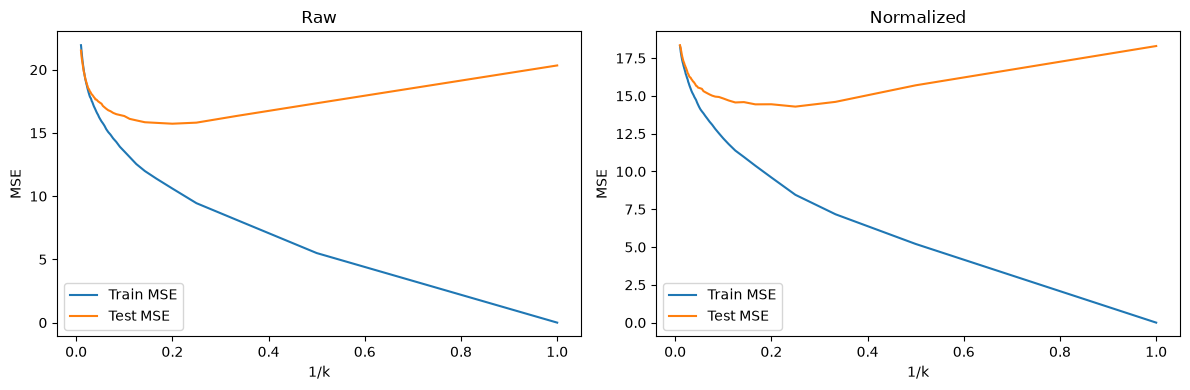

Best k without normalization: 5
Best k with normalization: 4


In [17]:
scaler = MinMaxScaler().fit(X_train)
datasets = [
    ("Raw", X_train, X_test),
    ("Normalized", scaler.transform(X_train), scaler.transform(X_test))
]

ks = np.arange(1, 101)
best_ks = {}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
knn_mse = {}
for ax, (name, train_x, test_x) in zip(axes, datasets):
    train_errors, test_errors = [], []

    for k in ks:
        knn = KNeighborsRegressor(n_neighbors=k).fit(train_x, y_train)
        train_errors.append(mean_squared_error(y_train, knn.predict(train_x)))
        test_errors.append(mean_squared_error(y_test, knn.predict(test_x)))
        
    knn_mse[name] = min(test_errors)
    best_k = ks[np.argmin(test_errors)]
    best_ks[name] = best_k

    ax.plot(1 / ks, train_errors, label="Train MSE")
    ax.plot(1 / ks, test_errors, label="Test MSE")
    ax.set(xlabel="1/k", ylabel="MSE", title=name)
    ax.legend()

plt.tight_layout()
plt.show()

print("Best k without normalization:", best_ks["Raw"])
print("Best k with normalization:", best_ks["Normalized"])

The best value of k is 5 for the raw features and 4 for the normalized features. In both plots, the test MSE first decreases and then increases as k grows.

**(j)**

In [18]:
print("Regression:", mean_squared_error(y_test, model.predict(B[terms])))
print("KNN Raw:", knn_mse["Raw"])
print("KNN Normalized:", knn_mse["Normalized"])

Regression: 18.660040495062617
KNN Raw: 15.726819842563568
KNN Normalized: 14.291333431295715


The reduced regression model has a test MSE of 18.6600. KNN performs better with both raw features, at 15.7268, and normalized features, at 14.2913. Normalized KNN has the lowest test error, so it gives the best predictions on this test set.

**(2) ISLR: 2.4.1**

**(a)**

A flexible method would usually perform better. Since n is very large and p is small, there is enough data to fit a more complicated model without overfitting too much.

**(b)**

A flexible method would usually perform worse. Since p is very large and n is small, the model is more likely to overfit.


**(c)**

A flexible method would usually perform better. If the relationship is highly non-linear, a flexible method can capture the shape better than a simple model.

**(d)**

A flexible method would usually perform worse. When the error variance is very high, there is a lot of noise in the data, and a flexible method may fit some of that noise instead of the true relationship.

**(3) ISLR: 2.4.7**

**(a)**

The Euclidean distance from each observation to the test point $(0,0,0)$ is

$$
d = \sqrt{(X_1-0)^2+(X_2-0)^2+(X_3-0)^2}.
$$

Therefore,

$$
d_1 = \sqrt{0^2+3^2+0^2} = 3
$$

$$
d_2 = \sqrt{2^2+0^2+0^2} = 2
$$

$$
d_3 = \sqrt{0^2+1^2+3^2} = \sqrt{10}
$$

$$
d_4 = \sqrt{0^2+1^2+2^2} = \sqrt{5}
$$

$$
d_5 = \sqrt{(-1)^2+0^2+1^2} = \sqrt{2}
$$

$$
d_6 = \sqrt{1^2+1^2+1^2} = \sqrt{3}
$$

**(b)**

For $K=1$, the nearest observation is observation 5, which is Green.
Therefore, the prediction is Green.

**(c)**

For $K=3$, the three nearest observations are observations 5, 6, and 2. Since two out of the three neighbors are Red, the prediction is Red.

**(d)**

The best value of $K$ shoud be small. A small $K$ gives a more flexible decision boundary, which can better capture a highly non-linear relationship.